# Towards a bound that saturates AND is sensibile al noise e alla complexity della underlying function


Il bound che plottiamo qui è, *finalmente*, 
\begin{equation}
\min\left\{\mathcal R_n (\mathcal H_d), O\left(\sqrt\frac{d}{n}\right)\right\}
\end{equation}
e com'è bello!

In [4]:
%run base.ipynb

mare


[checkpoint] bound: "bound" -> bound, params: ['empirical_rademacher']


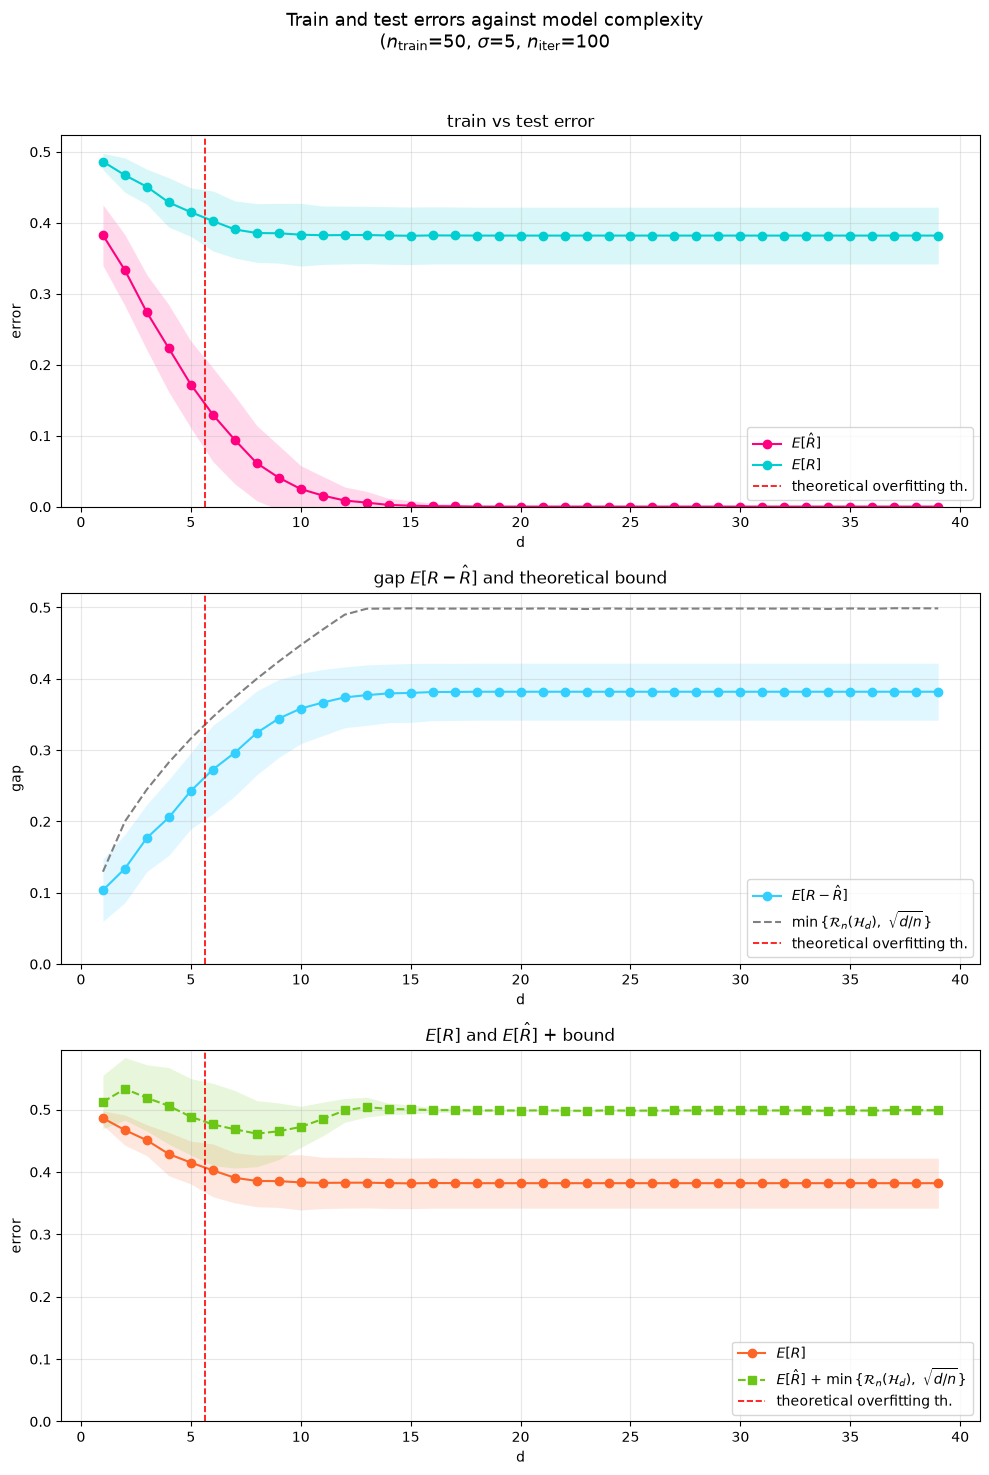

In [5]:
import numpy as np

# parameters 
n = 50
noise_std = 5
N = 10_000
T = 100
m = 10
n_test = 200_000

# model
mymodel = DecisionTreeClassifier

# function
from functools import partial
mysine = partial(sine, num_crossings = m)

# plots
emp_rad, std_rad = rademacher_curve(n_train=n, sigma=noise_std, num_iter=T, model=mymodel, fun=mysine, supp_size=N)

x_test = sample_x(n_test, N)
y_test = sample_y(x = x_test, f = mysine, sigma = noise_std)

hat_Rs, Rs, gaps, std_hat_Rs, std_Rs, std_gaps, predictions, x, y, x_grid = main_loop(
    x_test, y_test, n_train = n, sigma = noise_std, num_iter = T, model = mymodel,
    fun = mysine,
    supp_size = N)
plots(hat_Rs, Rs, gaps, std_hat_Rs=std_hat_Rs, std_Rs=std_Rs, std_gaps=std_gaps, 
      n_train = n, sigma = noise_std, num_iter= T, model = mymodel, 
      bound_name = "bound", bound_params = {"empirical_rademacher" : emp_rad}
      )

#### vedi che il bound non si sposta quando cambio il rumore!


[checkpoint] bound: "bound" -> bound, params: ['empirical_rademacher']
[checkpoint] bound: "bound" -> bound, params: ['empirical_rademacher']
[checkpoint] bound: "bound" -> bound, params: ['empirical_rademacher']


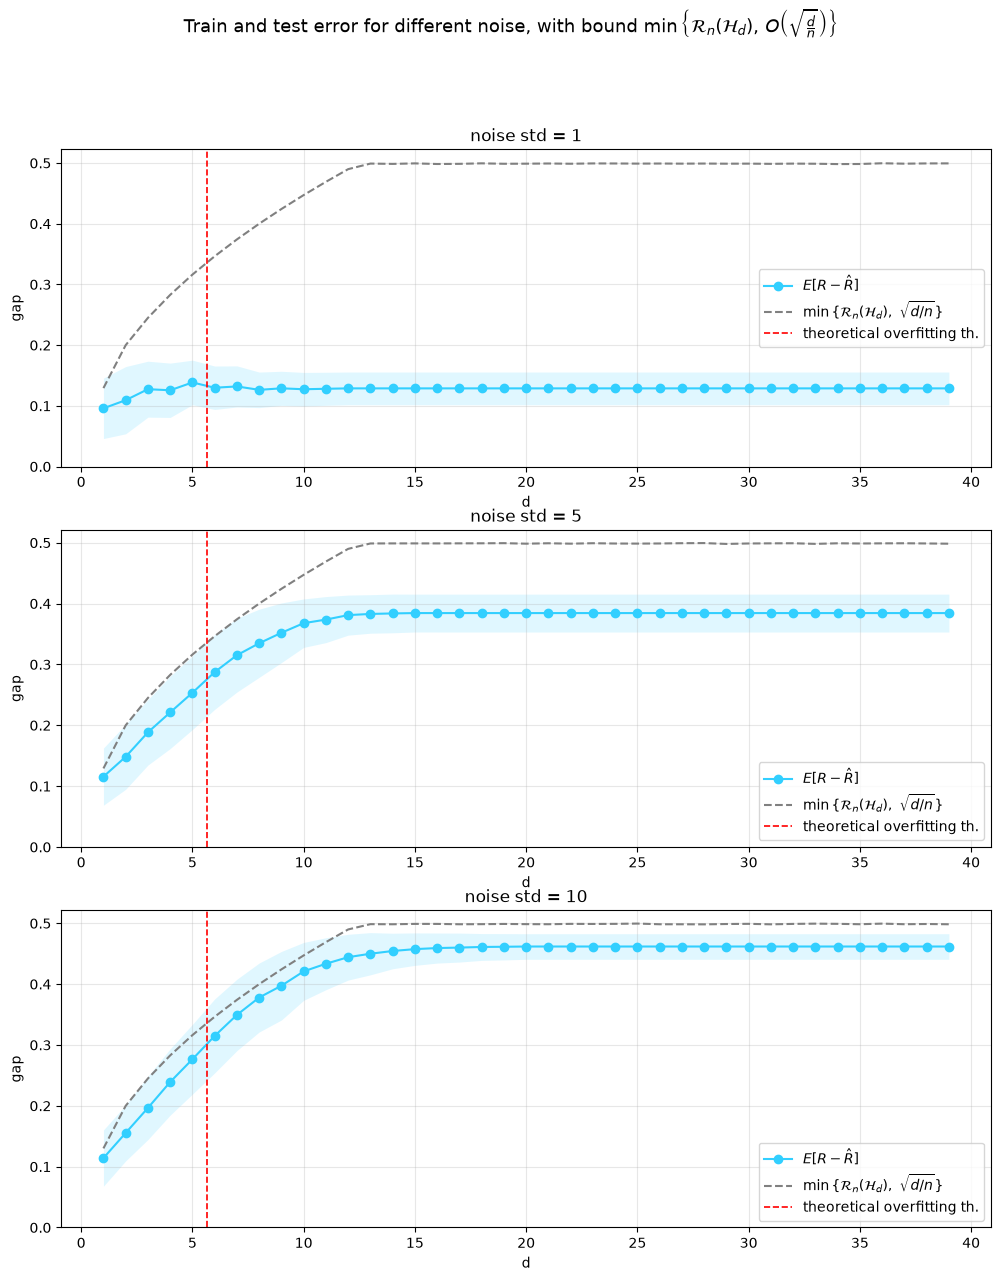

In [6]:
import matplotlib.pyplot as plt
fig, axs = plt.subplots(3, 1, figsize=(12, 14))
fig.suptitle(r'Train and test error for different noise, with bound $\min\left\{\mathcal{R}_n(\mathcal{H}_d),\, O\left(\sqrt{\frac{d}{n}}\right)\right\}$', fontsize=13)

# noises
my_noise_stds = [1, 5, 10]

for ax, my_noise_std in zip(axs.flat, my_noise_stds):
    emp_rad, std_rad = rademacher_curve(n_train=n, sigma=my_noise_std, num_iter=T, model=mymodel, fun=mysine, supp_size=N)

    # build test set
    x_test = sample_x(n_test, N)
    y_test = sample_y(x=x_test, f=mysine, sigma=my_noise_std)

    # build models and do plots 
    hat_Rs, Rs, gaps, std_hat_Rs, std_Rs, std_gaps, predictions, x, y, x_grid = main_loop(
        x_test, y_test, n_train=n, sigma=my_noise_std, num_iter=T, model=mymodel, fun=mysine, supp_size=N)
    plots(hat_Rs, Rs, gaps, std_hat_Rs=std_hat_Rs, std_Rs=std_Rs, std_gaps=std_gaps, 
          n_train=n, sigma=my_noise_std, num_iter=T, model=mymodel, 
          one=False, three=False, axes=[ax],
          bound_name = "bound", bound_params = {"empirical_rademacher" : emp_rad})
    ax.set_title(f'noise std = {my_noise_std}')

# Runtime ~2 min for 3 noise stds

[checkpoint] bound: "bound" -> bound, params: ['empirical_rademacher']
[checkpoint] bound: "bound" -> bound, params: ['empirical_rademacher']
[checkpoint] bound: "bound" -> bound, params: ['empirical_rademacher']


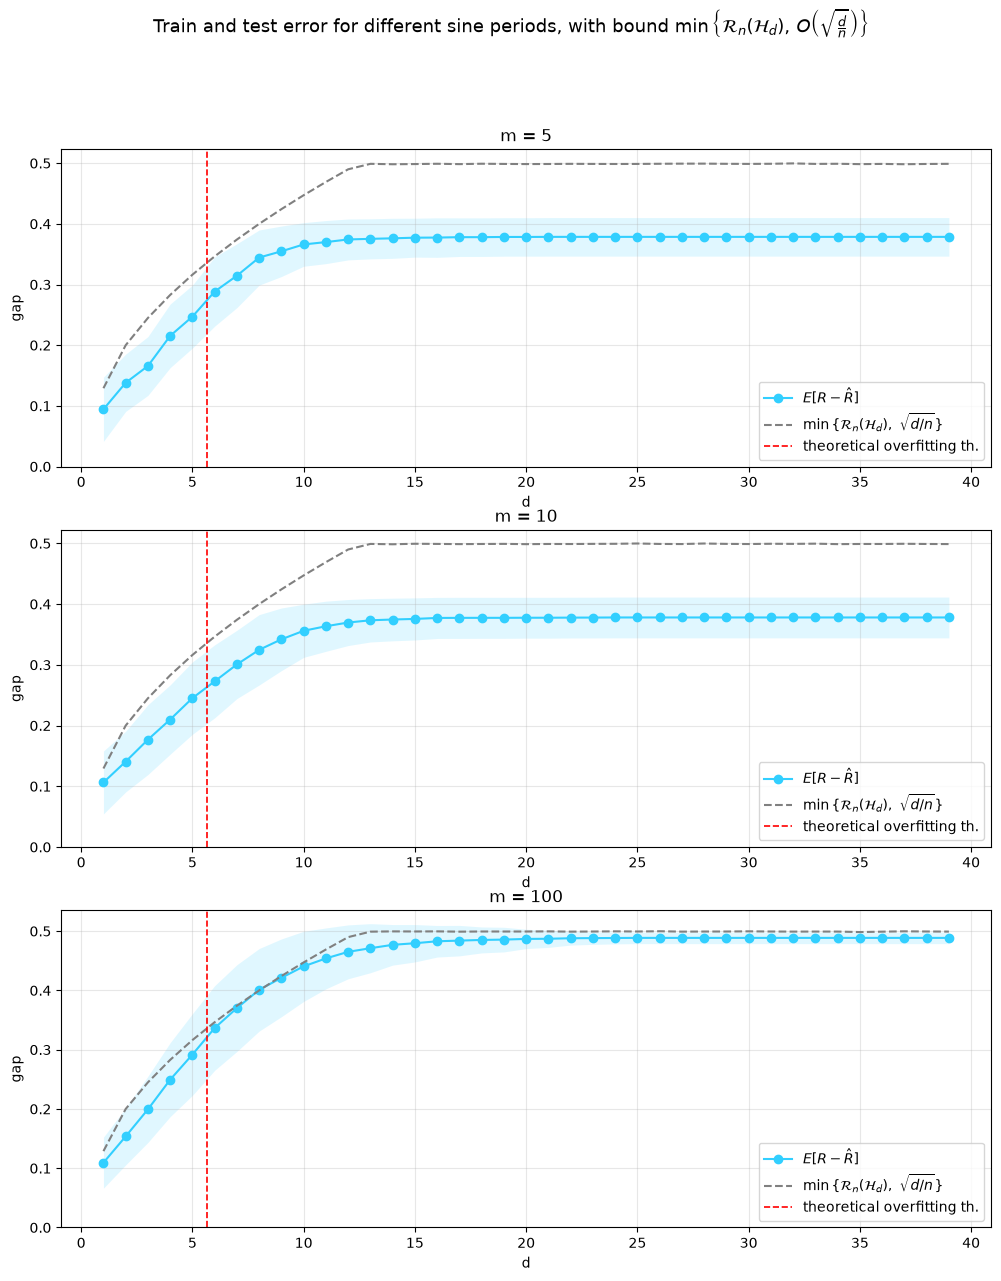

In [7]:
import matplotlib.pyplot as plt
fig, axs = plt.subplots(3, 1, figsize=(12, 14))
fig.suptitle(r'Train and test error for different sine periods, with bound $\min\left\{\mathcal{R}_n(\mathcal{H}_d),\, O\left(\sqrt{\frac{d}{n}}\right)\right\}$', fontsize=13)

# noises
my_ms = [5, 10, 100]

for ax, my_m in zip(axs.flat, my_ms):
    mysine = partial(sine, num_crossings = my_m)
    emp_rad, std_rad = rademacher_curve(n_train=n, sigma=noise_std, num_iter=T, model=mymodel, fun=mysine, supp_size=N)

    # build test set
    x_test = sample_x(n_test, N)
    y_test = sample_y(x=x_test, f=mysine, sigma=noise_std)

    # build models and do plots 
    hat_Rs, Rs, gaps, std_hat_Rs, std_Rs, std_gaps, predictions, x, y, x_grid = main_loop(
        x_test, y_test, n_train=n, sigma=noise_std, num_iter=T, model=mymodel, fun=mysine, supp_size=N)
    plots(hat_Rs, Rs, gaps, std_hat_Rs=std_hat_Rs, std_Rs=std_Rs, std_gaps=std_gaps, 
          n_train=n, sigma=noise_std, num_iter=T, model=mymodel, 
          one=False, three=False, axes=[ax],
          bound_name = "bound", bound_params = {"empirical_rademacher" : emp_rad})
    ax.set_title(f'm = {my_m}')